# Длительность инфекции
Одинаковый seed для экспоненциальной и фиксированной болезни.

Row,fixed,peak,time_peak,R_T,cases,I_T,vaccinated,population,balance
,Bool,Int64,Float64,Int64,Int64,Int64,Int64,Int64,Bool
1,false,175,21.4162,815,817,2,0,1000,true
2,true,299,12.0826,794,794,0,0,1000,true


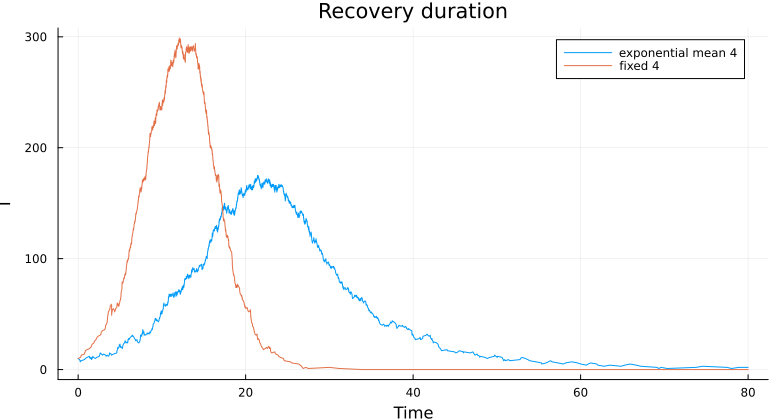

In [1]:
using DrWatson
@quickactivate "ContactEpidemics"
using ContactEpidemics.ContactProcesses
using ContactEpidemics.StudyTools
using DataFrames, CSV, Plots, Statistics


rows = NamedTuple[]
figure = plot(xlabel="Time",ylabel="I",title="Recovery duration")
for fixed in (false,true)
    m = simulate(config=Settings(;fixed),T=80.0)
    save_run(m;label="duration_$(fixed)",T=80.0)
    d = table(m)
    plot!(figure,d.t,d.I,label=fixed ? "fixed 4" : "exponential mean 4")
    push!(rows,(;fixed,run_metrics(m)...))
end
result = DataFrame(rows)
save_table("duration",result)
display(result)
savefig(figure,imagefile("duration"))
display(plot(figure; size=(780,420)))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*